INTIAL SETUP AND TESTING OF LIBRARIES

In [1]:
%pip install pyspark pyspark[sql] plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pyspark.sql import SparkSession

In [3]:
spark = SparkSession.builder.appName("Spark Practice").master("local[*]").getOrCreate()

In [4]:
df1 = spark.read.csv("day_wise.csv", header=True, inferSchema=True)
df1.show(5)

+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|      Date|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|No. of countries|
+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|2020-01-22|      555|    17|       28|   510|        0|         0|            0|              3.06|                 5.05|                 60.71|               6|
|2020-01-23|      654|    18|       30|   606|       99|         1|            2|              2.75|                 4.59|                  60.0|               8|
|2020-01-24|      941|    26|       36|   879|      287|         8|            6|              2.76|                 3.83|                 72.22|               9|
|2020-01-25|     1434|

Module 1: Data Loading & Schema Handling

Task 1: Load all CSV files into PySpark DataFrames


In [5]:
from pyspark.sql import SparkSession

In [6]:
# Initialize the Spark Session
spark = SparkSession.builder \
    .appName("Covid19_Analysis") \
    .getOrCreate()

In [7]:
# List of CSV files to be loaded
csv_files = [
    "full_grouped.csv",
    "covid_19_clean_complete.csv",
    "country_wise_latest.csv",
    "day_wise.csv",
    "usa_county_wise.csv",
    "worldometer_data.csv"
]

# Dictionary to hold the DataFrames for subsequent tasks
covid_dataframes = {}

# Process each file according to the requirements
for file in csv_files:
    print(f"\n--- Loading Dataset: {file} ---")
    
    # Load the CSV: Handle headers and infer schema automatically
    df = spark.read.csv(file, header=True, inferSchema=True)
    
    # Store the DataFrame in our dictionary
    # Use the filename (without .csv) as the key
    df_name = file.split(".")[0]
    covid_dataframes[df_name] = df
    
    # Requirement: Print the schema of the dataset
    df.printSchema()
    
    # Requirement: Count and print the number of rows
    print(f"Total Row Count for {file}: {df.count()}")

print("\nTask 1 successfully completed.")


--- Loading Dataset: full_grouped.csv ---
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Total Row Count for full_grouped.csv: 35156

--- Loading Dataset: covid_19_clean_complete.csv ---
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Total Row Count for covid_19_cl

Module 2: Data Cleaning Tasks

Task 2: Handle Missing Province/State Values


In [8]:
from pyspark.sql.functions import col

# 1. Load the dataset (using the existing 'spark' session)
df_covid = spark.read.csv("covid_19_clean_complete.csv", header=True, inferSchema=True)

# --- REQUIREMENT: Find rows where Province/State is null & Output Report ---
# Concept practiced: isNull(), filtering, and aggregation
print("--- Country-wise Null Count Report (Province/State) ---")
null_report = df_covid.filter(col("Province/State").isNull()) \
    .groupBy("Country/Region") \
    .count() \
    .orderBy("count", ascending=False)

# Displaying the report as requested
null_report.show()

# --- REQUIREMENT: Replace null values with "Unknown" ---
# Concept practiced: fillna()
# We use a subset to ensure we only modify the Province/State column
df_covid_cleaned = df_covid.fillna("Unknown", subset=["Province/State"])

# --- Verification ---
print(f"Total rows in dataset: {df_covid_cleaned.count()}")
print("Checking for remaining nulls in Province/State...")
remaining_nulls = df_covid_cleaned.filter(col("Province/State").isNull()).count()
print(f"Remaining nulls: {remaining_nulls}")

# Preview of the cleaned data
df_covid_cleaned.select("Province/State", "Country/Region", "Confirmed").show(10)

--- Country-wise Null Count Report (Province/State) ---
+--------------+-----+
|Country/Region|count|
+--------------+-----+
|          Chad|  188|
|      Paraguay|  188|
|        Russia|  188|
|         Yemen|  188|
|       Senegal|  188|
|    Cabo Verde|  188|
|        Sweden|  188|
|        Guyana|  188|
|       Eritrea|  188|
|   Philippines|  188|
|         Burma|  188|
|      Djibouti|  188|
|      Malaysia|  188|
|     Singapore|  188|
|          Fiji|  188|
|        Turkey|  188|
|        Malawi|  188|
|Western Sahara|  188|
|          Iraq|  188|
|       Germany|  188|
+--------------+-----+
only showing top 20 rows
Total rows in dataset: 49068
Checking for remaining nulls in Province/State...
Remaining nulls: 0
+--------------------+-------------------+---------+
|      Province/State|     Country/Region|Confirmed|
+--------------------+-------------------+---------+
|             Unknown|        Afghanistan|        0|
|             Unknown|            Albania|        0|
|   

Task 3: Standardize Country Names

Check if country names differ across:
full_grouped
country_wise_latest
worldometer_data

Example:
US vs USA
Korea vs South Korea
Create standardized naming.


In [9]:
from pyspark.sql.functions import col, when, regexp_replace

# 1. Load the three target DataFrames
df_full_grouped = spark.read.csv("full_grouped.csv", header=True, inferSchema=True)
df_country_wise = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)
df_worldometer = spark.read.csv("worldometer_data.csv", header=True, inferSchema=True)

# 2. Standardize Country Names
# Logic: Remove asterisks (e.g., 'Taiwan*'), convert 'USA' to 'US', and unify 'South Korea'
def standardize_names(df):
    return df.withColumn("Country/Region", 
        when(regexp_replace(col("Country/Region"), "\\*", "") == "USA", "US")
        .when(regexp_replace(col("Country/Region"), "\\*", "").contains("Korea"), "South Korea")
        .otherwise(regexp_replace(col("Country/Region"), "\\*", ""))
    )

# Apply the transformation to each DataFrame
df_full_grouped = standardize_names(df_full_grouped)
df_country_wise = standardize_names(df_country_wise)
df_worldometer = standardize_names(df_worldometer)

# 3. Verification: Output standardized results
print("Task 3 Verification: Unique standardized names (Sample from Worldometer):")
df_worldometer.select("Country/Region").distinct().sort("Country/Region").show(5000)

Task 3 Verification: Unique standardized names (Sample from Worldometer):
+--------------------+
|      Country/Region|
+--------------------+
|         Afghanistan|
|             Albania|
|             Algeria|
|             Andorra|
|              Angola|
| Antigua and Barbuda|
|           Argentina|
|             Armenia|
|               Aruba|
|           Australia|
|             Austria|
|          Azerbaijan|
|             Bahamas|
|             Bahrain|
|          Bangladesh|
|            Barbados|
|             Belarus|
|             Belgium|
|              Belize|
|               Benin|
|             Bermuda|
|              Bhutan|
|             Bolivia|
|Bosnia and Herzeg...|
|            Botswana|
|              Brazil|
|             Brunei |
|            Bulgaria|
|        Burkina Faso|
|             Burundi|
|                 CAR|
|          Cabo Verde|
|            Cambodia|
|            Cameroon|
|              Canada|
|Caribbean Netherl...|
|      Cayman Islands|
|     

Task 4: Remove Duplicate Daily Records

Check if duplicate entries exist for:
Country + Date
Remove duplicates.



In [10]:
# Task 4: Remove Duplicate Daily Records

# 1. Load the daily grouped dataset
df_full_grouped = spark.read.csv("full_grouped.csv", header=True, inferSchema=True)

# 2. Check initial count before removal
initial_count = df_full_grouped.count()
print(f"Initial count in full_grouped: {initial_count}")

# 3. Remove duplicates based on the combination of 'Country/Region' and 'Date'
# Concept: dropDuplicates()
df_full_grouped = df_full_grouped.dropDuplicates(["Country/Region", "Date"])

# 4. Check final count to verify removal
final_count = df_full_grouped.count()
print(f"Final count after removing duplicates: {final_count}")
print(f"Total duplicates removed: {initial_count - final_count}")

# Preview the cleaned daily records
df_full_grouped.select("Date", "Country/Region", "Confirmed").sort("Date", "Country/Region").show(10)

Initial count in full_grouped: 35156
Final count after removing duplicates: 35156
Total duplicates removed: 0
+----------+-------------------+---------+
|      Date|     Country/Region|Confirmed|
+----------+-------------------+---------+
|2020-01-22|        Afghanistan|        0|
|2020-01-22|            Albania|        0|
|2020-01-22|            Algeria|        0|
|2020-01-22|            Andorra|        0|
|2020-01-22|             Angola|        0|
|2020-01-22|Antigua and Barbuda|        0|
|2020-01-22|          Argentina|        0|
|2020-01-22|            Armenia|        0|
|2020-01-22|          Australia|        0|
|2020-01-22|            Austria|        0|
+----------+-------------------+---------+
only showing top 10 rows


Module 3: Aggregation Tasks

Task 5: Top 10 Countries by Total Confirmed Cases
Using country_wise_latest.csv

Output:

| Country | Confirmed |
Sort descending.
Visualization:
Bar chart



In [11]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Top 10 Countries by Total Confirmed Cases ---
+--------------+---------+
|       Country|Confirmed|
+--------------+---------+
|            US|  4290259|
|        Brazil|  2442375|
|         India|  1480073|
|        Russia|   816680|
|  South Africa|   452529|
|        Mexico|   395489|
|          Peru|   389717|
|         Chile|   347923|
|United Kingdom|   301708|
|          Iran|   293606|
+--------------+---------+



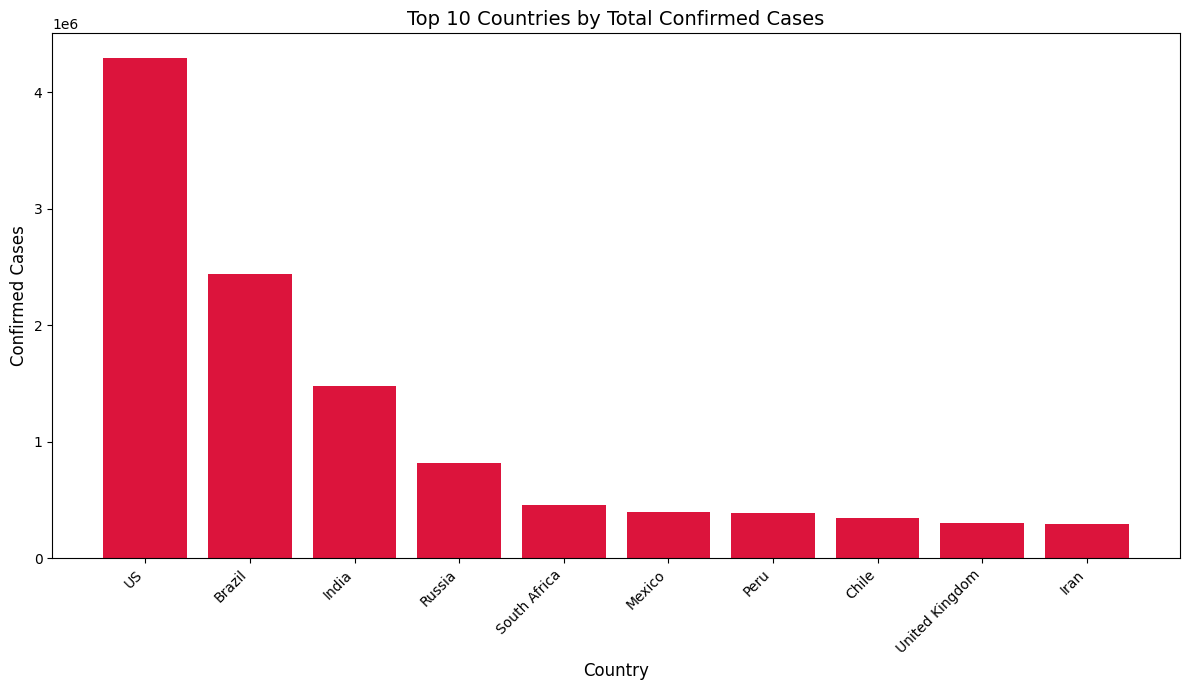

In [12]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

# 1. Load the country-wise latest dataset
df_country_wise = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)

# 2. Select, Sort, and Limit to Top 10
# Concept: orderBy() and limit()
df_top_10 = df_country_wise.select(col("Country/Region").alias("Country"), "Confirmed") \
    .orderBy(col("Confirmed").desc()) \
    .limit(10)

# 3. Output the table
print("--- Top 10 Countries by Total Confirmed Cases ---")
df_top_10.show()

# 4. Visualization: Bar Chart
# Convert to Pandas for plotting
pandas_df = df_top_10.toPandas()

plt.figure(figsize=(12, 7))
plt.bar(pandas_df["Country"], pandas_df["Confirmed"], color='crimson')
plt.xlabel("Country", fontsize=12)
plt.ylabel("Confirmed Cases", fontsize=12)
plt.title("Top 10 Countries by Total Confirmed Cases", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save or show the plot
plt.show()

Task 6: Top 10 Countries by Death Rate

Using:
Deaths / 100 Cases
Find top countries with highest death rate.

Visualization:
Horizontal bar chart


--- Top 10 Countries by Death Rate (per 100 Cases) ---
+--------------+------------------+
|       Country|Deaths / 100 Cases|
+--------------+------------------+
|         Yemen|             28.56|
|United Kingdom|             15.19|
|       Belgium|             14.79|
|         Italy|             14.26|
|        France|             13.71|
|       Hungary|              13.4|
|   Netherlands|             11.53|
|        Mexico|             11.13|
|         Spain|             10.44|
|Western Sahara|              10.0|
+--------------+------------------+



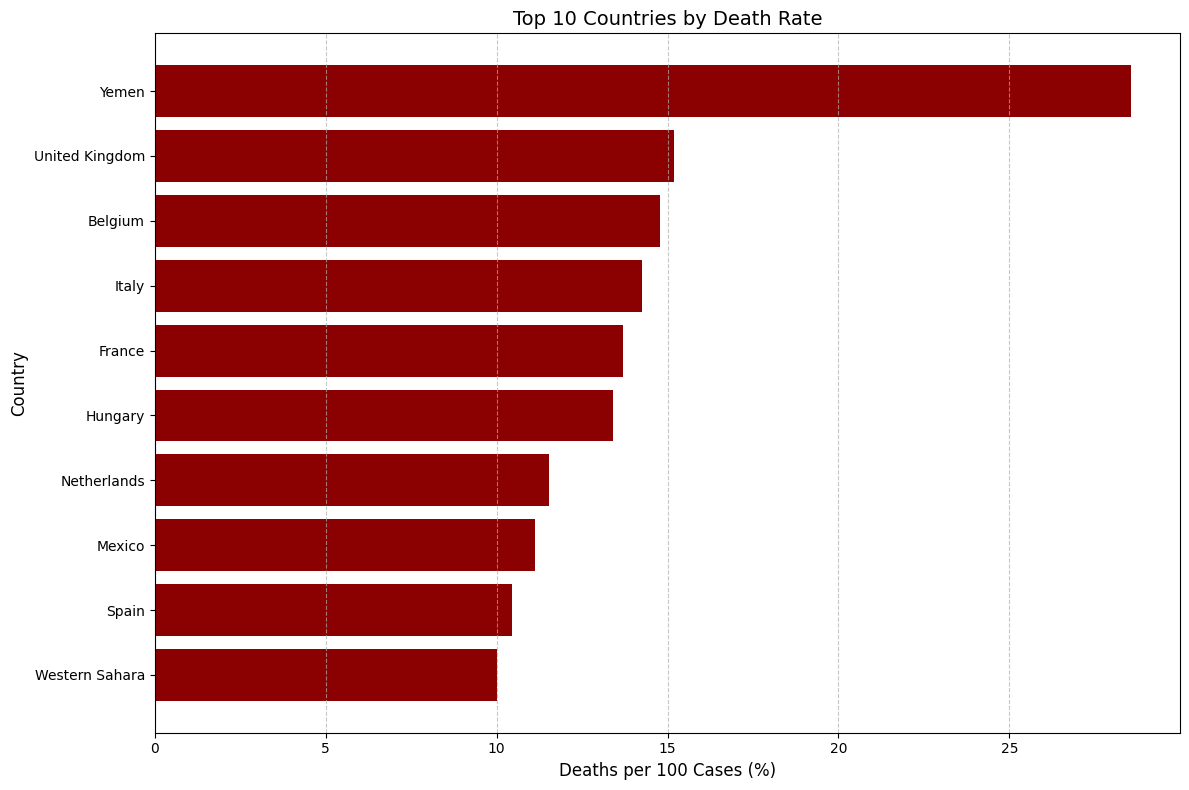

In [13]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

# 1. Load the country-wise latest dataset
df_country_wise = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)

# 2. Select and Sort by Death Rate (Deaths / 100 Cases)
# Concept: orderBy() and limit()
df_death_rate = df_country_wise.select(col("Country/Region").alias("Country"), "Deaths / 100 Cases") \
    .orderBy(col("Deaths / 100 Cases").desc()) \
    .limit(10)

# 3. Output the table results
print("--- Top 10 Countries by Death Rate (per 100 Cases) ---")
df_death_rate.show()

# 4. Visualization: Horizontal Bar Chart
pandas_death_df = df_death_rate.toPandas()

plt.figure(figsize=(12, 8))
# Note: We reverse the dataframe for plotting so the highest value is at the top
plt.barh(pandas_death_df["Country"][::-1], pandas_death_df["Deaths / 100 Cases"][::-1], color='darkred')
plt.xlabel("Deaths per 100 Cases (%)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.title("Top 10 Countries by Death Rate", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save or display the plot
plt.show()

Task 7: WHO Region-wise Total Cases

Using:
full_grouped.csv

Find:
total confirmed
total deaths
total recovered
grouped by WHO region.

Visualization:
Pie chart / stacked bar chart



--- WHO Region Statistics (As of 2020-07-27) ---
+--------------------+---------------+------------+---------------+
|          WHO Region|Total_Confirmed|Total_Deaths|Total_Recovered|
+--------------------+---------------+------------+---------------+
|            Americas|        8839286|      342732|        4468616|
|              Europe|        3299523|      211144|        1993723|
|     South-East Asia|        1835297|       41349|        1156933|
|Eastern Mediterra...|        1490744|       38339|        1201400|
|              Africa|         723207|       12223|         440645|
|     Western Pacific|         292428|        8249|         206770|
+--------------------+---------------+------------+---------------+



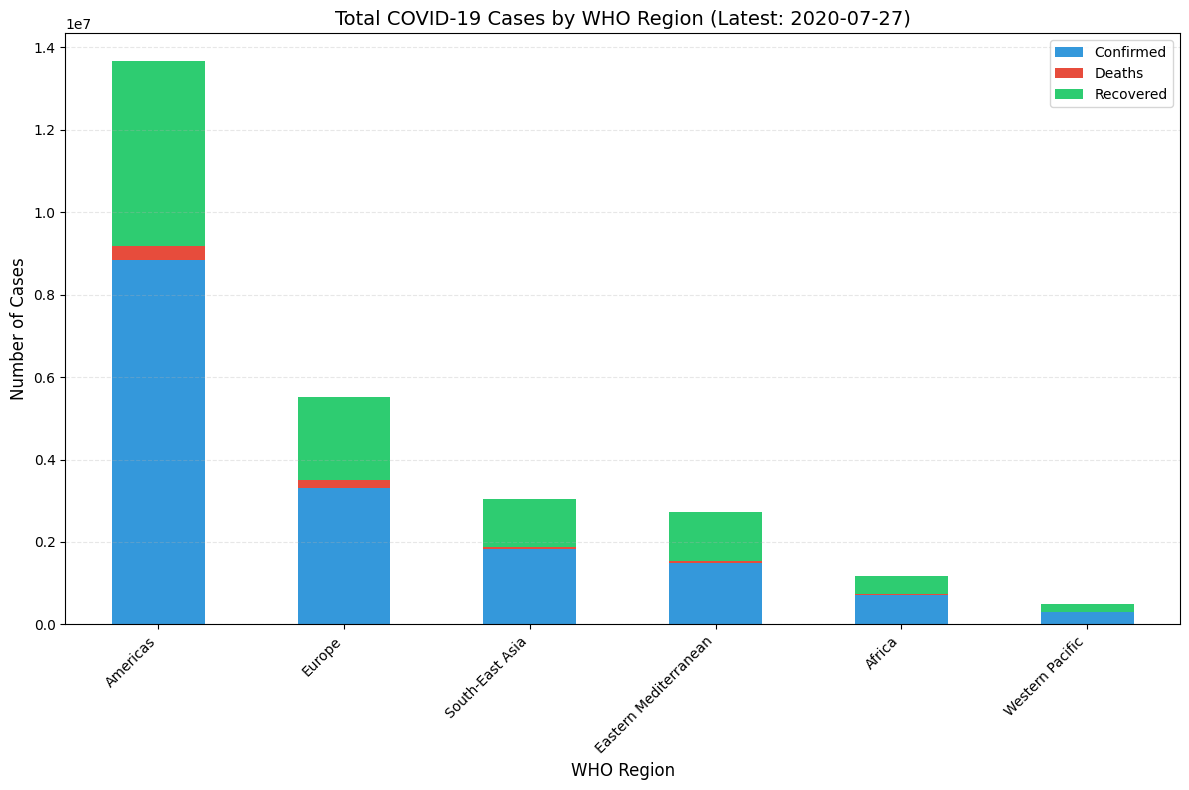

In [14]:
from pyspark.sql.functions import sum, max
import matplotlib.pyplot as plt

# 1. Load the daily grouped dataset
df_full = spark.read.csv("full_grouped.csv", header=True, inferSchema=True)

# 2. Identify the latest date in the dataset
latest_date = df_full.select(max("Date")).collect()[0][0]

# 3. Filter for latest data and aggregate by WHO Region
# Concepts: groupBy() and agg()
df_region_totals = df_full.filter(col("Date") == latest_date) \
    .groupBy("WHO Region") \
    .agg(
        sum("Confirmed").alias("Total_Confirmed"),
        sum("Deaths").alias("Total_Deaths"),
        sum("Recovered").alias("Total_Recovered")
    ).orderBy(col("Total_Confirmed").desc())

# 4. Output the table results
print(f"--- WHO Region Statistics (As of {latest_date}) ---")
df_region_totals.show()

# 5. Visualization: Stacked Bar Chart
pandas_region_df = df_region_totals.toPandas().set_index("WHO Region")

pandas_region_df.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title(f'Total COVID-19 Cases by WHO Region (Latest: {latest_date})', fontsize=14)
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(["Confirmed", "Deaths", "Recovered"])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

Module 4: Time-Series Analysis

Task 8: Daily Global New Cases Trend
Using day_wise.csv

Find:
date
new cases

Visualization:
Line chart


--- Daily Global New Cases Trend (First 10 Days) ---
+----------+---------+
|      Date|New cases|
+----------+---------+
|2020-01-22|        0|
|2020-01-23|       99|
|2020-01-24|      287|
|2020-01-25|      493|
|2020-01-26|      684|
|2020-01-27|      809|
|2020-01-28|     2651|
|2020-01-29|      588|
|2020-01-30|     2068|
|2020-01-31|     1693|
+----------+---------+
only showing top 10 rows


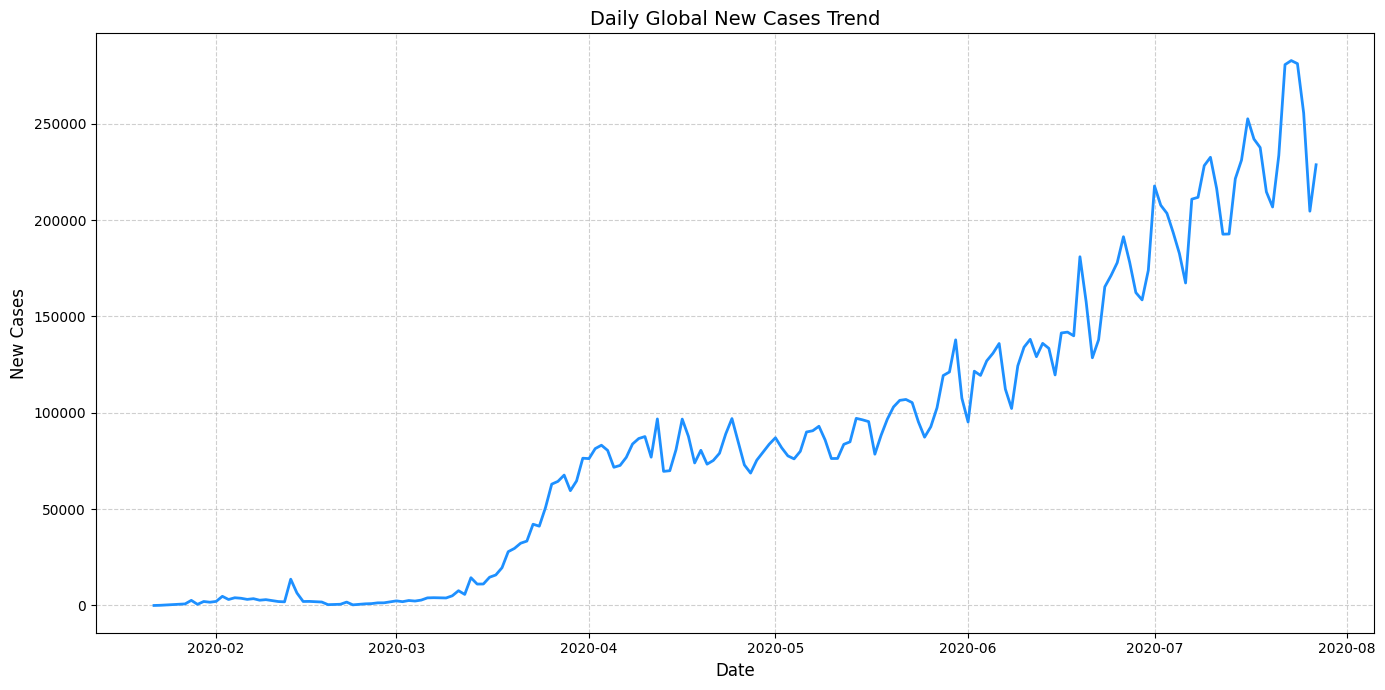

In [15]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

# 1. Load the day-wise dataset
df_day_wise = spark.read.csv("day_wise.csv", header=True, inferSchema=True)

# 2. Select the required columns and sort by date for a proper time-series trend
# Concept: select() and orderBy()
df_trend = df_day_wise.select("Date", "New cases") \
    .orderBy("Date")

# 3. Output the daily trend (Sample)
print("--- Daily Global New Cases Trend (First 10 Days) ---")
df_trend.show(10)

# 4. Visualization: Line Chart
# Convert to Pandas for plotting time-series data
pandas_trend_df = df_trend.toPandas()

plt.figure(figsize=(14, 7))
plt.plot(pandas_trend_df["Date"], pandas_trend_df["New cases"], color='dodgerblue', linewidth=2)

plt.title('Daily Global New Cases Trend', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('New Cases', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save or display the plot
plt.show()

Task 9: Daily Global Death Growth Trend
Using day_wise.csv

Calculate:
daily death growth percentage

Formula:
(new_deaths / previous_day_deaths) * 100

Concepts:
window functions
lag

Visualization:
Line chart


--- Daily Global Death Growth Percentage Trend ---
+----------+------+----------+-----------------------+
|      Date|Deaths|New deaths|Death_Growth_Percentage|
+----------+------+----------+-----------------------+
|2020-01-23|    18|         1|                   5.88|
|2020-01-24|    26|         8|                  44.44|
|2020-01-25|    42|        16|                  61.54|
|2020-01-26|    56|        14|                  33.33|
|2020-01-27|    82|        26|                  46.43|
|2020-01-28|   131|        49|                  59.76|
|2020-01-29|   133|         2|                   1.53|
|2020-01-30|   171|        38|                  28.57|
|2020-01-31|   213|        42|                  24.56|
|2020-02-01|   259|        46|                   21.6|
+----------+------+----------+-----------------------+
only showing top 10 rows


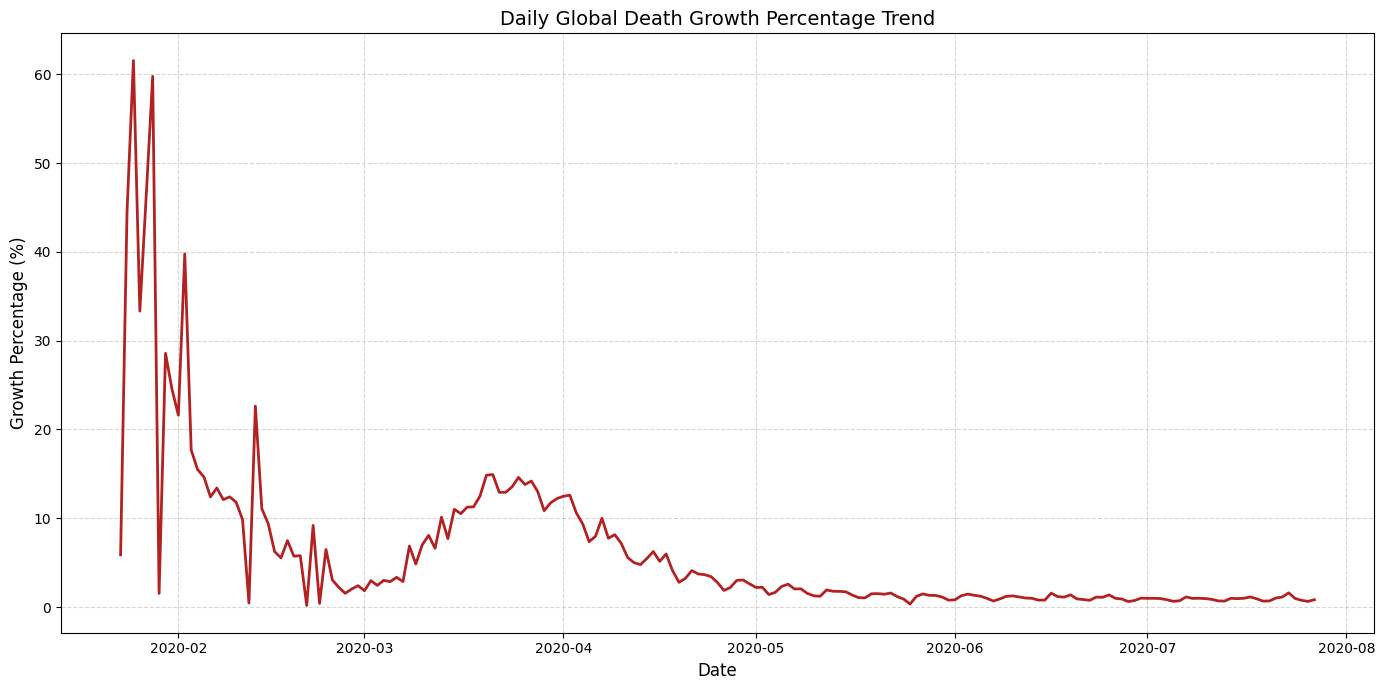

In [16]:
from pyspark.sql import Window
from pyspark.sql.functions import col, lag, round
import matplotlib.pyplot as plt

# 1. Load the day-wise dataset
df_day_wise = spark.read.csv("day_wise.csv", header=True, inferSchema=True)

# 2. Define Window specification (sorted by Date)
# Concept: window functions
window_spec = Window.orderBy("Date")

# 3. Calculate the Growth Percentage
# Formula: (new_deaths / previous_day_deaths) * 100
# Concept: lag
df_growth = df_day_wise.withColumn("Prev_Day_Deaths", lag("Deaths", 1).over(window_spec)) \
    .withColumn("Death_Growth_Percentage", 
                round((col("New deaths") / col("Prev_Day_Deaths")) * 100, 2))

# 4. Filter out the first row (where no previous day exists)
df_growth_final = df_growth.filter(col("Death_Growth_Percentage").isNotNull())

# 5. Output the results (Sample)
print("--- Daily Global Death Growth Percentage Trend ---")
df_growth_final.select("Date", "Deaths", "New deaths", "Death_Growth_Percentage").show(10)

# 6. Visualization: Line Chart
# Convert to Pandas for visualization
pd_growth = df_growth_final.select("Date", "Death_Growth_Percentage").toPandas()

plt.figure(figsize=(14, 7))
plt.plot(pd_growth["Date"], pd_growth["Death_Growth_Percentage"], color='firebrick', linewidth=2)

plt.title('Daily Global Death Growth Percentage Trend', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth Percentage (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Task 10: Monthly COVID Case Growth
Using full_grouped.csv

Extract:
month
total confirmed cases

Concepts:
month()
groupBy()

Visualization:
Monthly trend chart


--- Monthly Global COVID-19 Case Growth (Total New Cases) ---
+-----+---------------+
|Month|Total_New_Cases|
+-----+---------------+
|    1|           9372|
|    2|          75379|
|    3|         786064|
|    4|        2412383|
|    5|        2921042|
|    6|        4265801|
|    7|        6030911|
+-----+---------------+



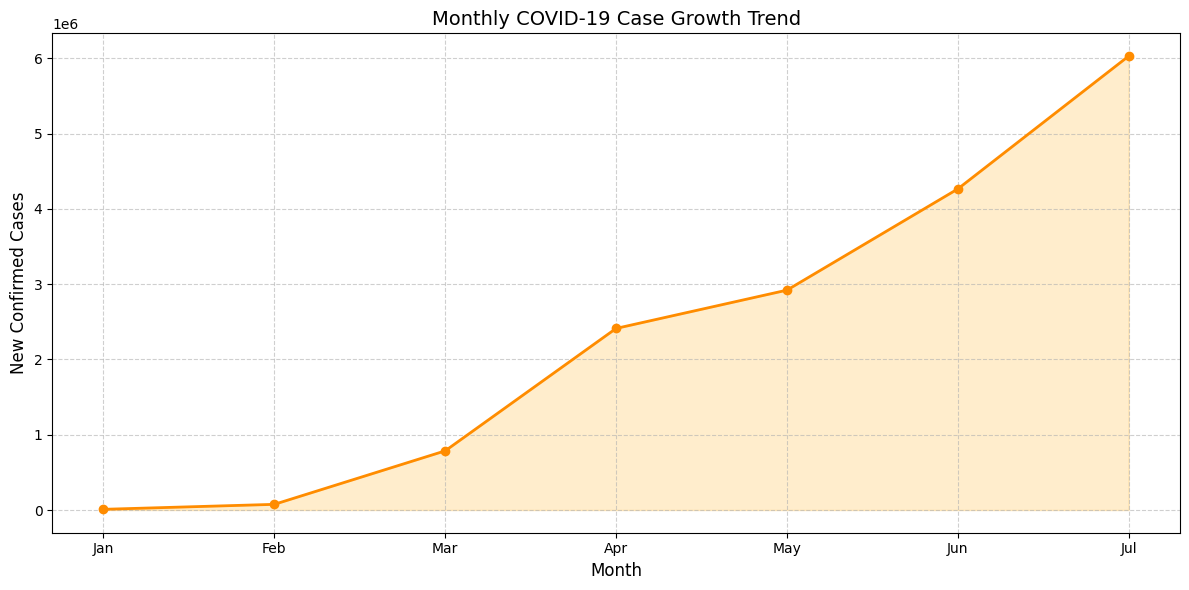

In [17]:
from pyspark.sql.functions import month, col, sum
import matplotlib.pyplot as plt

# 1. Load the dataset
df_full = spark.read.csv("full_grouped.csv", header=True, inferSchema=True)

# 2. Extract Month and calculate total monthly growth
# Concepts practiced: month() and groupBy()
df_monthly = df_full.withColumn("Month", month(col("Date"))) \
    .groupBy("Month") \
    .agg(sum("New cases").alias("Total_New_Cases")) \
    .orderBy("Month")

# 3. Output the results table
print("--- Monthly Global COVID-19 Case Growth (Total New Cases) ---")
df_monthly.show()

# 4. Visualization: Monthly Trend Chart
pandas_monthly = df_monthly.toPandas()

# Optional: Map month numbers to names for better labeling
month_map = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul"}
pandas_monthly['Month_Name'] = pandas_monthly['Month'].map(month_map)

plt.figure(figsize=(12, 6))
plt.plot(pandas_monthly["Month_Name"], pandas_monthly["Total_New_Cases"], marker='o', color='darkorange', linewidth=2)
plt.fill_between(pandas_monthly["Month_Name"], pandas_monthly["Total_New_Cases"], color='orange', alpha=0.2)

plt.title('Monthly COVID-19 Case Growth Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('New Confirmed Cases', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Module 5: Window Function Tasks
Task 11: Top 5 Most Affected Countries Per WHO Region

Using:
country_wise_latest.csv

For each WHO region:
rank countries based on confirmed cases
return top 5

Concepts:
Window.partitionBy()
dense_rank()

Visualization:
Grouped bar chart


In [19]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Top 5 Most Affected Countries Per WHO Region ---
+--------------------+--------------+---------+----+
|          WHO Region|Country/Region|Confirmed|Rank|
+--------------------+--------------+---------+----+
|              Africa|  South Africa|   452529|   1|
|              Africa|       Nigeria|    41180|   2|
|              Africa|         Ghana|    33624|   3|
|              Africa|       Algeria|    27973|   4|
|              Africa|         Kenya|    17975|   5|
|            Americas|            US|  4290259|   1|
|            Americas|        Brazil|  2442375|   2|
|            Americas|        Mexico|   395489|   3|
|            Americas|          Peru|   389717|   4|
|            Americas|         Chile|   347923|   5|
|Eastern Mediterra...|          Iran|   293606|   1|
|Eastern Mediterra...|      Pakistan|   274289|   2|
|Eastern Mediterra...|  Saudi Arabia|   268934|   3|
|Eastern Mediterra...|          Iraq|   112585|   4|
|Eastern Mediterra...|         Qatar|   109597

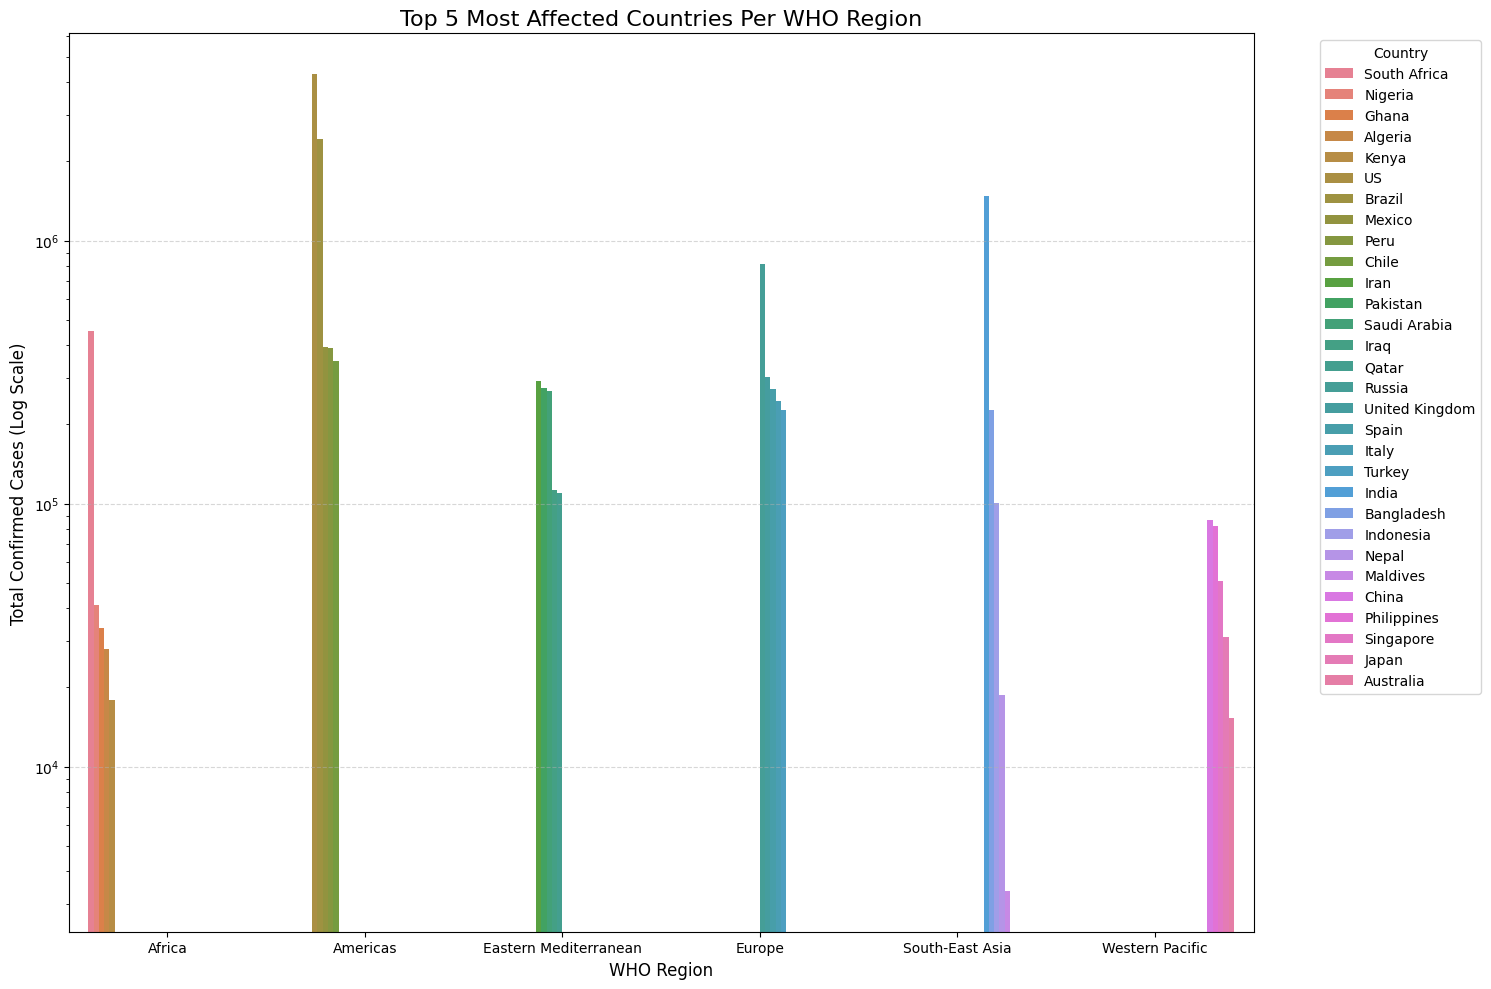

In [20]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, dense_rank
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df_country_wise = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)

# 2. Define the Window Specification
# Concept: Window.partitionBy()
# We partition by Region and order by Confirmed cases descending
window_spec = Window.partitionBy("WHO Region").orderBy(col("Confirmed").desc())

# 3. Apply Dense Rank and filter for top 5
# Concept: dense_rank()
df_ranked = df_country_wise.withColumn("Rank", dense_rank().over(window_spec)) \
    .filter(col("Rank") <= 5) \
    .select("WHO Region", "Country/Region", "Confirmed", "Rank") \
    .orderBy("WHO Region", "Rank")

# 4. Output the table results
print("--- Top 5 Most Affected Countries Per WHO Region ---")
df_ranked.show(30)

# 5. Visualization: Grouped Bar Chart
# Convert to Pandas for plotting
pd_top5 = df_ranked.toPandas()

plt.figure(figsize=(15, 10))
sns.barplot(data=pd_top5, x='WHO Region', y='Confirmed', hue='Country/Region')

plt.title('Top 5 Most Affected Countries Per WHO Region', fontsize=16)
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('Total Confirmed Cases (Log Scale)', fontsize=12)
plt.yscale('log')  # Used to better visualize regions with widely different case volumes
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Task 12: Country-wise Daily Case Increase
Using full_grouped.csv

For each country:
calculate:
today_confirmed - yesterday_confirmed

Concepts:
lag
partition window

Visualization:
Country trend chart


--- Daily Case Increase: US (Recent 10 Days) ---
+----------+--------------+---------+--------------+
|      Date|Country/Region|Confirmed|Daily_Increase|
+----------+--------------+---------+--------------+
|2020-07-27|            US|  4290259|         56336|
|2020-07-26|            US|  4233923|         54953|
|2020-07-25|            US|  4178970|         66439|
|2020-07-24|            US|  4112531|         73715|
|2020-07-23|            US|  4038816|         68695|
|2020-07-22|            US|  3970121|         70910|
|2020-07-21|            US|  3899211|         64534|
|2020-07-20|            US|  3834677|         61417|
|2020-07-19|            US|  3773260|         61847|
|2020-07-18|            US|  3711413|         63698|
+----------+--------------+---------+--------------+
only showing top 10 rows


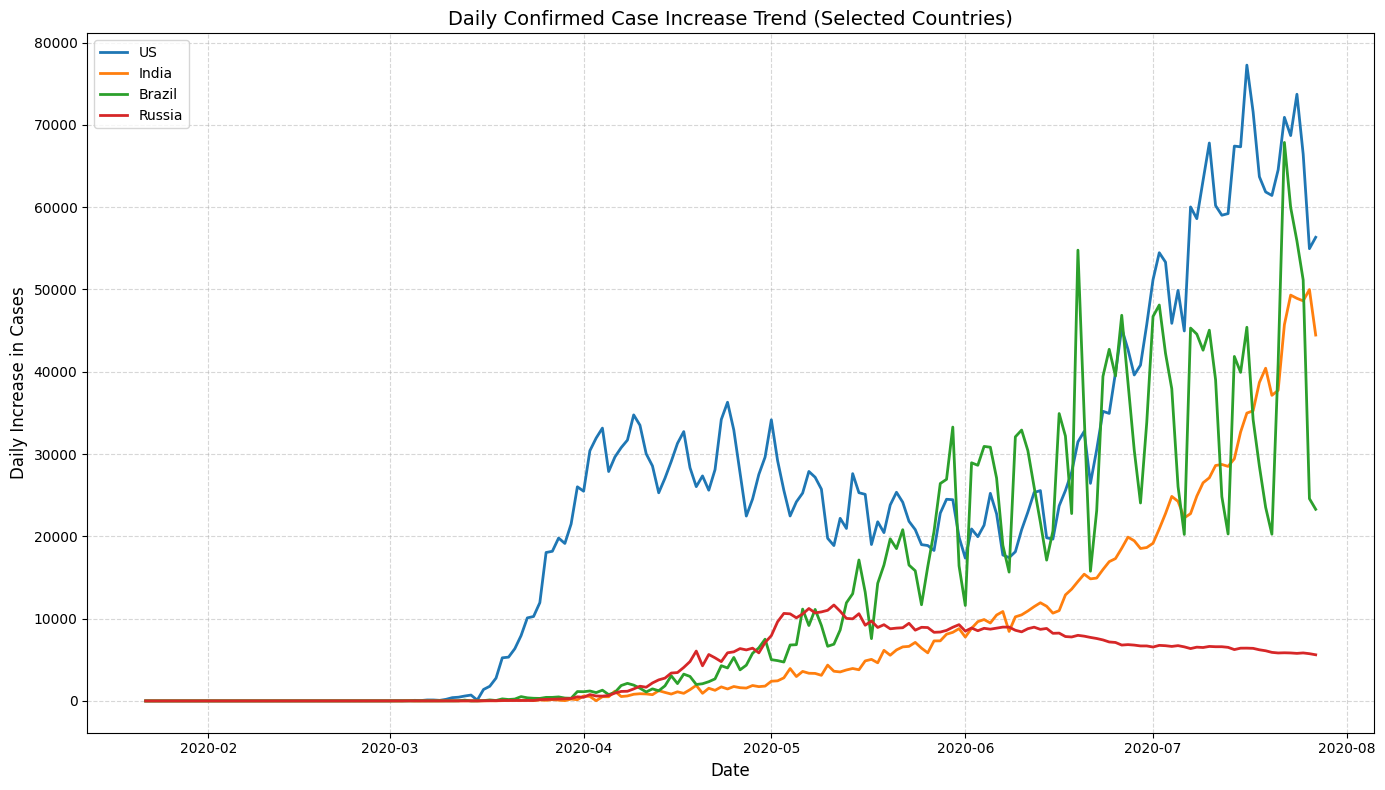

In [21]:
from pyspark.sql import Window
from pyspark.sql.functions import col, lag, coalesce, lit
import matplotlib.pyplot as plt

# 1. Load the grouped dataset
df_full = spark.read.csv("full_grouped.csv", header=True, inferSchema=True)

# 2. Define the Window Specification
# Concept: partition window ordered by Date
window_spec = Window.partitionBy("Country/Region").orderBy("Date")

# 3. Calculate Daily Increase using lag()
# Formula: today_confirmed - yesterday_confirmed
# coalesce() is used to handle the first day of data (setting it to 0)
df_daily_increase = df_full.withColumn("Prev_Day_Confirmed", lag("Confirmed", 1).over(window_spec)) \
    .withColumn("Daily_Increase", 
                coalesce(col("Confirmed") - col("Prev_Day_Confirmed"), lit(0)))

# 4. Output the result for a sample country (e.g., US)
print("--- Daily Case Increase: US (Recent 10 Days) ---")
df_daily_increase.filter(col("Country/Region") == "US") \
    .select("Date", "Country/Region", "Confirmed", "Daily_Increase") \
    .orderBy(col("Date").desc()) \
    .show(10)

# 5. Visualization: Country Trend Chart
# Selecting major countries for a comparative line chart
countries_to_plot = ['US', 'India', 'Brazil', 'Russia']
pandas_df = df_daily_increase.filter(col("Country/Region").isin(countries_to_plot)).toPandas()

plt.figure(figsize=(14, 8))
for country in countries_to_plot:
    country_data = pandas_df[pandas_df['Country/Region'] == country]
    plt.plot(country_data['Date'], country_data['Daily_Increase'], label=country, linewidth=2)

plt.title('Daily Confirmed Case Increase Trend (Selected Countries)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Increase in Cases', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Module 6: Join Operations

Task 13: Compare Latest Dataset Sources
Join:
country_wise_latest.csv
worldometer_data.csv

Join on:
Country/Region

Compare:
Confirmed cases difference
Death difference
Recovery difference

Output:
Find countries where both datasets show large mismatches.

Concepts:
joins
calculated columns


In [22]:
from pyspark.sql.functions import col, abs as spark_abs

# 1. Load the datasets
df_country_wise = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)
df_worldometer = spark.read.csv("worldometer_data.csv", header=True, inferSchema=True)

# 2. Standardize names to ensure the join works (from Task 3 logic)
def standardize(df):
    return df.withColumn("Country/Region", 
        when(col("Country/Region") == "USA", "US")
        .otherwise(col("Country/Region")))

df_cw_clean = standardize(df_country_wise)
df_wm_clean = standardize(df_worldometer)

# 3. Join the datasets on Country/Region
# We use aliases to distinguish between columns with similar meanings
df_joined = df_cw_clean.alias("cw").join(
    df_wm_clean.alias("wm"), 
    on="Country/Region", 
    how="inner"
)

# 4. Calculate differences
# Note: Worldometer uses 'TotalCases', 'TotalDeaths', 'TotalRecovered'
df_comparison = df_joined.withColumn(
    "Confirmed_Diff", spark_abs(col("cw.Confirmed") - col("wm.TotalCases"))
).withColumn(
    "Death_Diff", spark_abs(col("cw.Deaths") - col("wm.TotalDeaths"))
).withColumn(
    "Recovery_Diff", spark_abs(col("cw.Recovered") - col("wm.TotalRecovered"))
)

# 5. Output: Find countries with large mismatches (Top 10 by Confirmed Difference)
print("--- Top 10 Dataset Mismatches (Country Wise vs Worldometer) ---")
df_comparison.select(
    "Country/Region", 
    "cw.Confirmed", "wm.TotalCases", "Confirmed_Diff",
    "cw.Deaths", "wm.TotalDeaths", "Death_Diff"
).orderBy(col("Confirmed_Diff").desc()).show(10)

--- Top 10 Dataset Mismatches (Country Wise vs Worldometer) ---
+--------------+---------+----------+--------------+------+-----------+----------+
|Country/Region|Confirmed|TotalCases|Confirmed_Diff|Deaths|TotalDeaths|Death_Diff|
+--------------+---------+----------+--------------+------+-----------+----------+
|            US|  4290259|   5032179|        741920|148011|     162804|     14793|
|         India|  1480073|   2025409|        545336| 33408|      41638|      8230|
|        Brazil|  2442375|   2917562|        475187| 87618|      98644|     11026|
|      Colombia|   257101|    357710|        100609|  8777|      11939|      3162|
|  South Africa|   452529|    538184|         85655|  7067|       9604|      2537|
|         Spain|   272421|    354530|         82109| 28432|      28500|        68|
|        Mexico|   395489|    462690|         67201| 44022|      50517|      6495|
|          Peru|   389717|    455409|         65692| 18418|      20424|      2006|
|     Argentina|   1674

Task 14: Population vs Total Cases
Using worldometer_data.csv

Calculate:
infection_rate = (TotalCases / Population) * 100
Find top countries with highest infection rate.

Visualization:
Scatter plot / bar chart


--- Top 10 Countries by Infection Rate (% of Population) ---
+--------------+----------+----------+--------------+
|Country/Region|Population|TotalCases|Infection_Rate|
+--------------+----------+----------+--------------+
|         Qatar|   2807805|    112092|          3.99|
| French Guiana|    299385|      8127|          2.71|
|       Bahrain|   1706669|     42889|          2.51|
|    San Marino|     33938|       699|          2.06|
|         Chile|  19132514|    366671|          1.92|
|        Panama|   4321282|     71418|          1.65|
|        Kuwait|   4276658|     70045|          1.64|
|          Oman|   5118446|     80713|          1.58|
|           USA| 331198130|   5032179|          1.52|
|  Vatican City|       801|        12|           1.5|
+--------------+----------+----------+--------------+



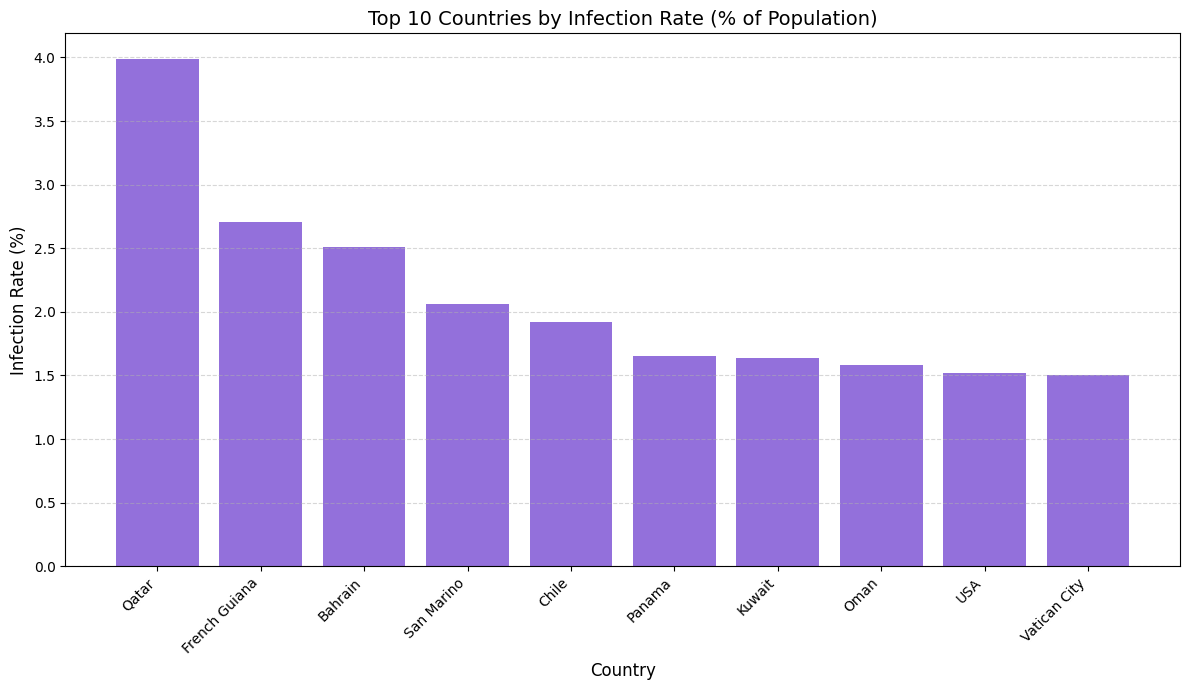

In [23]:
from pyspark.sql.functions import col, round
import matplotlib.pyplot as plt

# 1. Load the worldometer dataset
df_worldometer = spark.read.csv("worldometer_data.csv", header=True, inferSchema=True)

# 2. Calculate Infection Rate
# Formula: (TotalCases / Population) * 100
# We use round() to make the percentage readable
df_infection_rate = df_worldometer.filter(col("Population").isNotNull()) \
    .withColumn("Infection_Rate", 
                round((col("TotalCases") / col("Population")) * 100, 2))

# 3. Get Top 10 Countries with highest infection rate
df_top_infection = df_infection_rate.select("Country/Region", "Population", "TotalCases", "Infection_Rate") \
    .orderBy(col("Infection_Rate").desc()) \
    .limit(10)

# 4. Output the table
print("--- Top 10 Countries by Infection Rate (% of Population) ---")
df_top_infection.show()

# 5. Visualization: Bar Chart
pandas_infection_df = df_top_infection.toPandas()

plt.figure(figsize=(12, 7))
plt.bar(pandas_infection_df["Country/Region"], pandas_infection_df["Infection_Rate"], color='mediumpurple')

plt.title('Top 10 Countries by Infection Rate (% of Population)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Infection Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Task 14: Population vs Total Cases
Using worldometer_data.csv

Calculate:
infection_rate = (TotalCases / Population) * 100
Find top countries with highest infection rate.

Visualization:
Scatter plot / bar chart


--- Top 10 Countries by Infection Rate (% of Population) ---
+--------------+----------+----------+--------------+
|Country/Region|Population|TotalCases|Infection_Rate|
+--------------+----------+----------+--------------+
|         Qatar|   2807805|    112092|          3.99|
| French Guiana|    299385|      8127|          2.71|
|       Bahrain|   1706669|     42889|          2.51|
|    San Marino|     33938|       699|          2.06|
|         Chile|  19132514|    366671|          1.92|
|        Panama|   4321282|     71418|          1.65|
|        Kuwait|   4276658|     70045|          1.64|
|          Oman|   5118446|     80713|          1.58|
|           USA| 331198130|   5032179|          1.52|
|  Vatican City|       801|        12|           1.5|
+--------------+----------+----------+--------------+



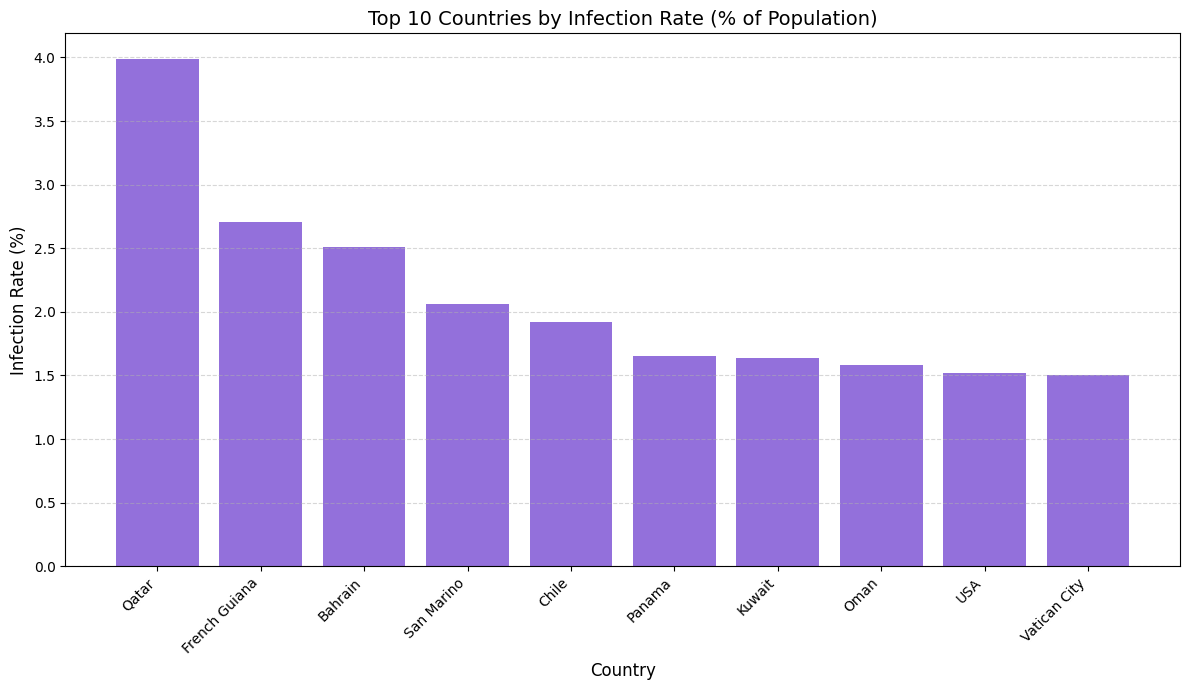

In [24]:
from pyspark.sql.functions import col, round
import matplotlib.pyplot as plt

# 1. Load the worldometer dataset
df_worldometer = spark.read.csv("worldometer_data.csv", header=True, inferSchema=True)

# 2. Calculate Infection Rate
# Formula: (TotalCases / Population) * 100
# We use round() to make the percentage readable
df_infection_rate = df_worldometer.filter(col("Population").isNotNull()) \
    .withColumn("Infection_Rate", 
                round((col("TotalCases") / col("Population")) * 100, 2))

# 3. Get Top 10 Countries with highest infection rate
df_top_infection = df_infection_rate.select("Country/Region", "Population", "TotalCases", "Infection_Rate") \
    .orderBy(col("Infection_Rate").desc()) \
    .limit(10)

# 4. Output the table
print("--- Top 10 Countries by Infection Rate (% of Population) ---")
df_top_infection.show()

# 5. Visualization: Bar Chart
pandas_infection_df = df_top_infection.toPandas()

plt.figure(figsize=(12, 7))
plt.bar(pandas_infection_df["Country/Region"], pandas_infection_df["Infection_Rate"], color='mediumpurple')

plt.title('Top 10 Countries by Infection Rate (% of Population)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Infection Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Task 15: USA State-wise Case Distribution
Using usa_county_wise.csv

Group by:
Province_State
Find number of counties reported per state.

Visualization:
US map / bar chart


--- Number of Counties Reported Per State ---
+--------------+------------+
|Province_State|County_Count|
+--------------+------------+
|         Texas|         256|
|       Georgia|         161|
|      Virginia|         135|
|      Kentucky|         122|
|      Missouri|         118|
|        Kansas|         107|
|      Illinois|         104|
|North Carolina|         102|
|          Iowa|         101|
|     Tennessee|          97|
|      Nebraska|          95|
|       Indiana|          94|
|          Ohio|          90|
|     Minnesota|          89|
|      Michigan|          87|
|   Mississippi|          84|
|   Puerto Rico|          80|
|      Oklahoma|          79|
|      Arkansas|          77|
|     Wisconsin|          74|
+--------------+------------+
only showing top 20 rows


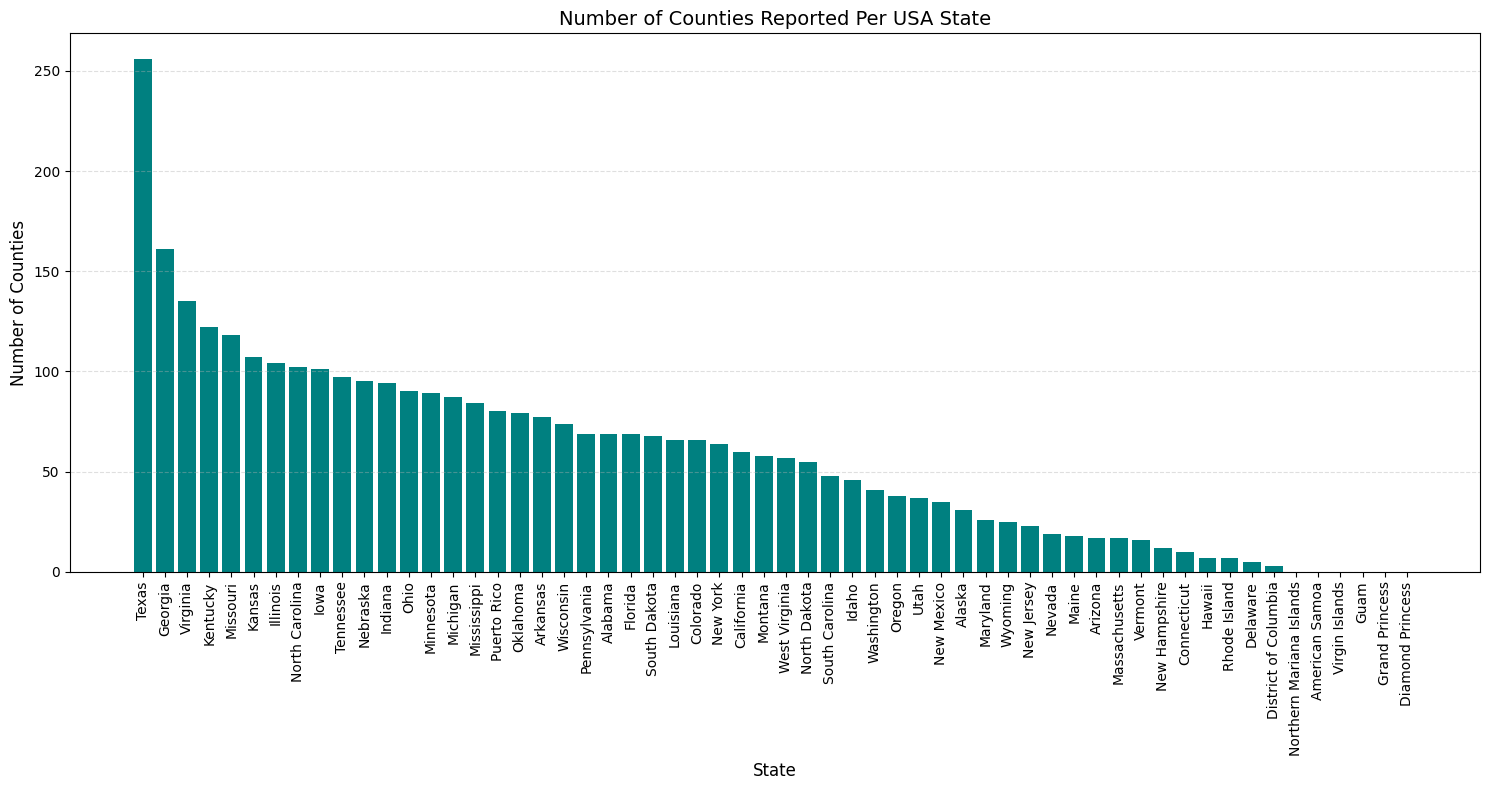

In [25]:
from pyspark.sql.functions import col, countDistinct
import matplotlib.pyplot as plt

# 1. Load the USA county-wise dataset
df_usa = spark.read.csv("usa_county_wise.csv", header=True, inferSchema=True)

# 2. Group by Province_State and count the number of unique counties (Admin2)
# Concept: groupBy() and countDistinct()
df_state_counties = df_usa.groupBy("Province_State") \
    .agg(countDistinct("Admin2").alias("County_Count")) \
    .orderBy(col("County_Count").desc())

# 3. Output the report table
print("--- Number of Counties Reported Per State ---")
df_state_counties.show()

# 4. Visualization: Bar Chart
pandas_usa_df = df_state_counties.toPandas()

plt.figure(figsize=(15, 8))
plt.bar(pandas_usa_df["Province_State"], pandas_usa_df["County_Count"], color='teal')

plt.title('Number of Counties Reported Per USA State', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Counties', fontsize=12)
plt.xticks(rotation=90) # Rotate state names for readability
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

Task 16: Latitude-Longitude Based Case Clusters
Using covid_19_clean_complete.csv

Create dataset containing:
latitude
longitude
confirmed cases

Visualization:
Geo scatter plot


--- Geographic Case Clusters (As of 2020-07-27) ---
+--------+---------+---------+-------------------+
|     Lat|     Long|Confirmed|     Country/Region|
+--------+---------+---------+-------------------+
|33.93911|67.709953|    36263|        Afghanistan|
| 41.1533|  20.1683|     4880|            Albania|
| 28.0339|   1.6596|    27973|            Algeria|
| 42.5063|   1.5218|      907|            Andorra|
|-11.2027|  17.8739|      950|             Angola|
| 17.0608| -61.7964|       86|Antigua and Barbuda|
|-38.4161| -63.6167|   167416|          Argentina|
| 40.0691|  45.0382|    37390|            Armenia|
|-35.4735| 149.0124|      113|          Australia|
|-33.8688| 151.2093|     3699|          Australia|
+--------+---------+---------+-------------------+
only showing top 10 rows


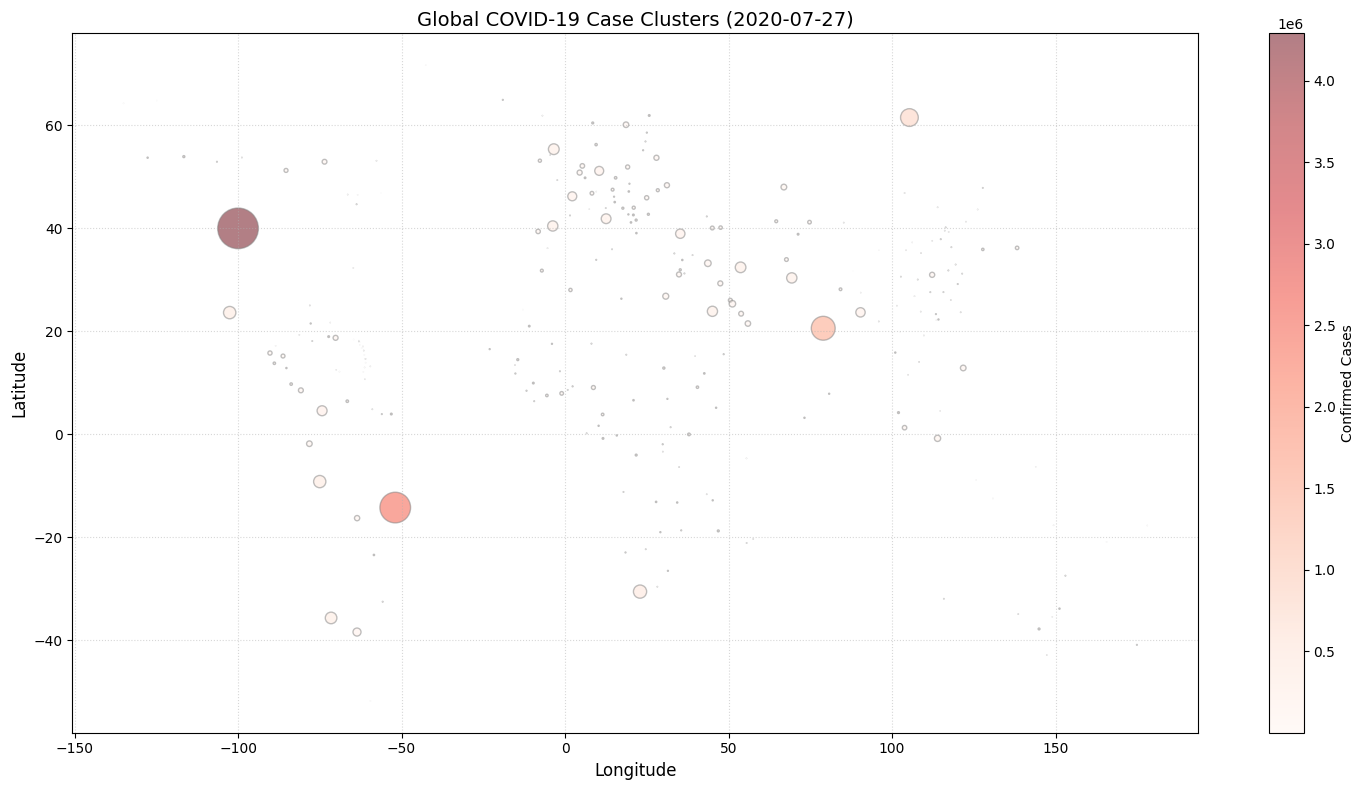

In [26]:
from pyspark.sql.functions import col, max
import matplotlib.pyplot as plt

# 1. Load the dataset
df_geo = spark.read.csv("covid_19_clean_complete.csv", header=True, inferSchema=True)

# 2. Identify the latest date to get the current snapshot
latest_date = df_geo.select(max("Date")).collect()[0][0]

# 3. Create the dataset for clusters
# We filter for the latest date and select geographic coordinates and confirmed cases
df_clusters = df_geo.filter(col("Date") == latest_date) \
    .select("Lat", "Long", "Confirmed", "Country/Region") \
    .filter(col("Lat").isNotNull() & col("Long").isNotNull())

# 4. Output the dataset (Sample)
print(f"--- Geographic Case Clusters (As of {latest_date}) ---")
df_clusters.show(10)

# 5. Visualization: Geo Scatter Plot
# Convert to pandas for plotting
pandas_geo = df_clusters.toPandas()

plt.figure(figsize=(15, 8))
# We use Longitude as X and Latitude as Y
# The size (s) of the point is scaled by the number of confirmed cases
# We divide Confirmed by a factor (e.g., 5000) so the points don't overlap too much
scatter = plt.scatter(
    pandas_geo["Long"], 
    pandas_geo["Lat"], 
    s=pandas_geo["Confirmed"] / 5000, 
    alpha=0.5, 
    c=pandas_geo["Confirmed"], 
    cmap='Reds',
    edgecolors='grey'
)

plt.title(f'Global COVID-19 Case Clusters ({latest_date})', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.colorbar(scatter, label='Confirmed Cases')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

plt.show()

Module 8: Advanced Analytical Tasks

Task 17: Recovery Rate Analysis
Using country_wise_latest.csv

Formula:
(Recovered / Confirmed) * 100

Find:
best recovery countries
worst recovery countries

Visualization:
Bar chart


--- Top 10 Countries with BEST Recovery Rates (%) ---
+--------------+-------------+
|Country/Region|Recovery_Rate|
+--------------+-------------+
|      Holy See|        100.0|
|       Grenada|        100.0|
|      Dominica|        100.0|
|      Djibouti|        98.38|
|       Iceland|        98.33|
|        Brunei|        97.87|
|   New Zealand|        97.24|
|         Qatar|        97.02|
|      Malaysia|         96.6|
|     Mauritius|        96.51|
+--------------+-------------+

--- Top 10 Countries with WORST Recovery Rates (%) ---
+--------------+-------------+
|Country/Region|Recovery_Rate|
+--------------+-------------+
|        Canada|          0.0|
|    Mozambique|          0.0|
|        Serbia|          0.0|
|        Sweden|          0.0|
|         Syria|          0.0|
|   Timor-Leste|          0.0|
|   Netherlands|         0.35|
|United Kingdom|         0.48|
|       Namibia|         5.48|
|      Botswana|         8.53|
+--------------+-------------+



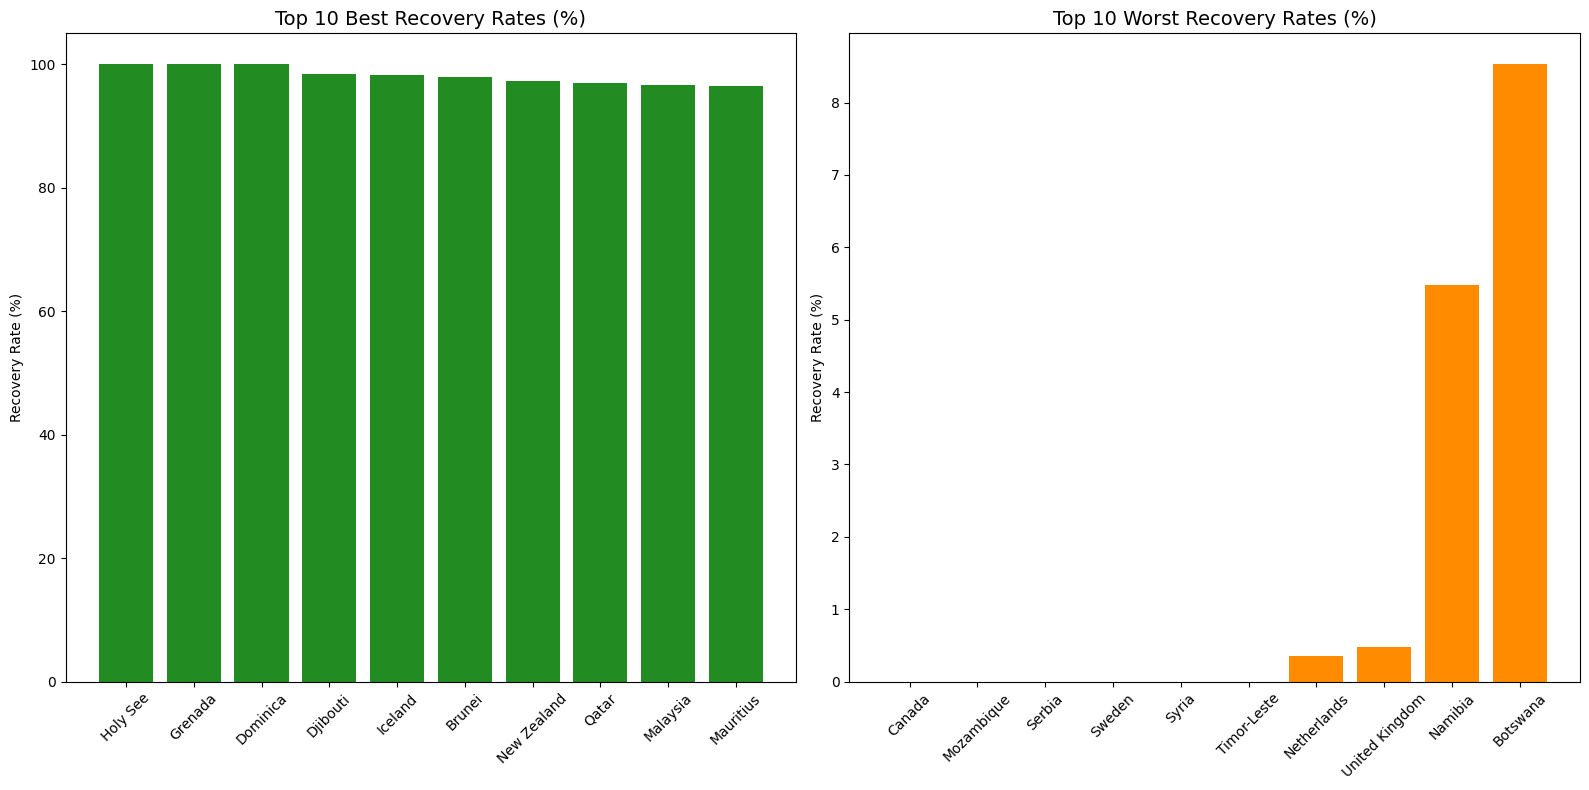

In [27]:
from pyspark.sql.functions import col, round
import matplotlib.pyplot as plt

# 1. Load the country-wise latest dataset
df_country = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)

# 2. Calculate Recovery Rate
# Formula: (Recovered / Confirmed) * 100
# We filter Confirmed > 0 to avoid division by zero errors
df_recovery = df_country.filter(col("Confirmed") > 0) \
    .withColumn("Recovery_Rate", round((col("Recovered") / col("Confirmed")) * 100, 2))

# 3. Identify Best and Worst Recovery Countries
# Top 10 Best
df_best = df_recovery.select("Country/Region", "Recovery_Rate") \
    .orderBy(col("Recovery_Rate").desc()) \
    .limit(10)

# Top 10 Worst
df_worst = df_recovery.select("Country/Region", "Recovery_Rate") \
    .orderBy(col("Recovery_Rate").asc()) \
    .limit(10)

# 4. Output the results
print("--- Top 10 Countries with BEST Recovery Rates (%) ---")
df_best.show()

print("--- Top 10 Countries with WORST Recovery Rates (%) ---")
df_worst.show()

# 5. Visualization: Side-by-Side Bar Charts
pandas_best = df_best.toPandas()
pandas_worst = df_worst.toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Best Recovery Plot
ax1.bar(pandas_best['Country/Region'], pandas_best['Recovery_Rate'], color='forestgreen')
ax1.set_title('Top 10 Best Recovery Rates (%)', fontsize=14)
ax1.set_ylabel('Recovery Rate (%)')
ax1.tick_params(axis='x', rotation=45)

# Worst Recovery Plot
ax2.bar(pandas_worst['Country/Region'], pandas_worst['Recovery_Rate'], color='darkorange')
ax2.set_title('Top 10 Worst Recovery Rates (%)', fontsize=14)
ax2.set_ylabel('Recovery Rate (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Task 18: Active Case Burden Analysis

Find countries where:
Active cases > recovered cases

Output:
High-risk countries list


In [28]:
from pyspark.sql.functions import col

# 1. Load the country-wise latest dataset
df_latest = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)

# 2. Find countries where Active cases > Recovered cases
# This represents a "High-Risk" situation for the healthcare infrastructure
# Concept practiced: filtering with comparison
df_high_risk = df_latest.filter(col("Active") > col("Recovered")) \
    .select("Country/Region", "Active", "Recovered") \
    .orderBy(col("Active").desc())

# 3. Output the High-risk countries list
print("--- High-Risk Countries List (Active cases > Recovered cases) ---")
df_high_risk.show(20)

# 4. Final Count Requirement
total_high_risk = df_high_risk.count()
print(f"Total number of High-Risk countries identified: {total_high_risk}")

--- High-Risk Countries List (Active cases > Recovered cases) ---
+------------------+-------+---------+
|    Country/Region| Active|Recovered|
+------------------+-------+---------+
|                US|2816444|  1325804|
|    United Kingdom| 254427|     1437|
|            France| 108928|    81212|
|            Canada| 107514|        0|
|         Argentina|  91782|    72575|
|            Sweden|  73695|        0|
|       Philippines|  53649|    26446|
|             Egypt|  52992|    34838|
|       Netherlands|  47064|      189|
|           Bolivia|  47056|    21478|
|           Ecuador|  40733|    34896|
|           Belgium|  39154|    17452|
|            Israel|  36378|    27133|
|          Honduras|  33536|     5039|
|Dominican Republic|  32869|    30204|
|            Serbia|  23598|        0|
|           Nigeria|  22117|    18203|
|        Costa Rica|  11902|     3824|
|             Kenya|   9857|     7833|
|          Ethiopia|   7933|     6386|
+------------------+-------+---------

Task 19: Identify Pandemic Peaks
Using day_wise.csv

Find dates where:
new cases were maximum
new deaths were maximum

Visualization:
Peak markers on line chart


--- Pandemic Peaks Identified ---
Global Peak New Cases: 282756 occurred on 2020-07-23
Global Peak New Deaths: 9966 occurred on 2020-07-23


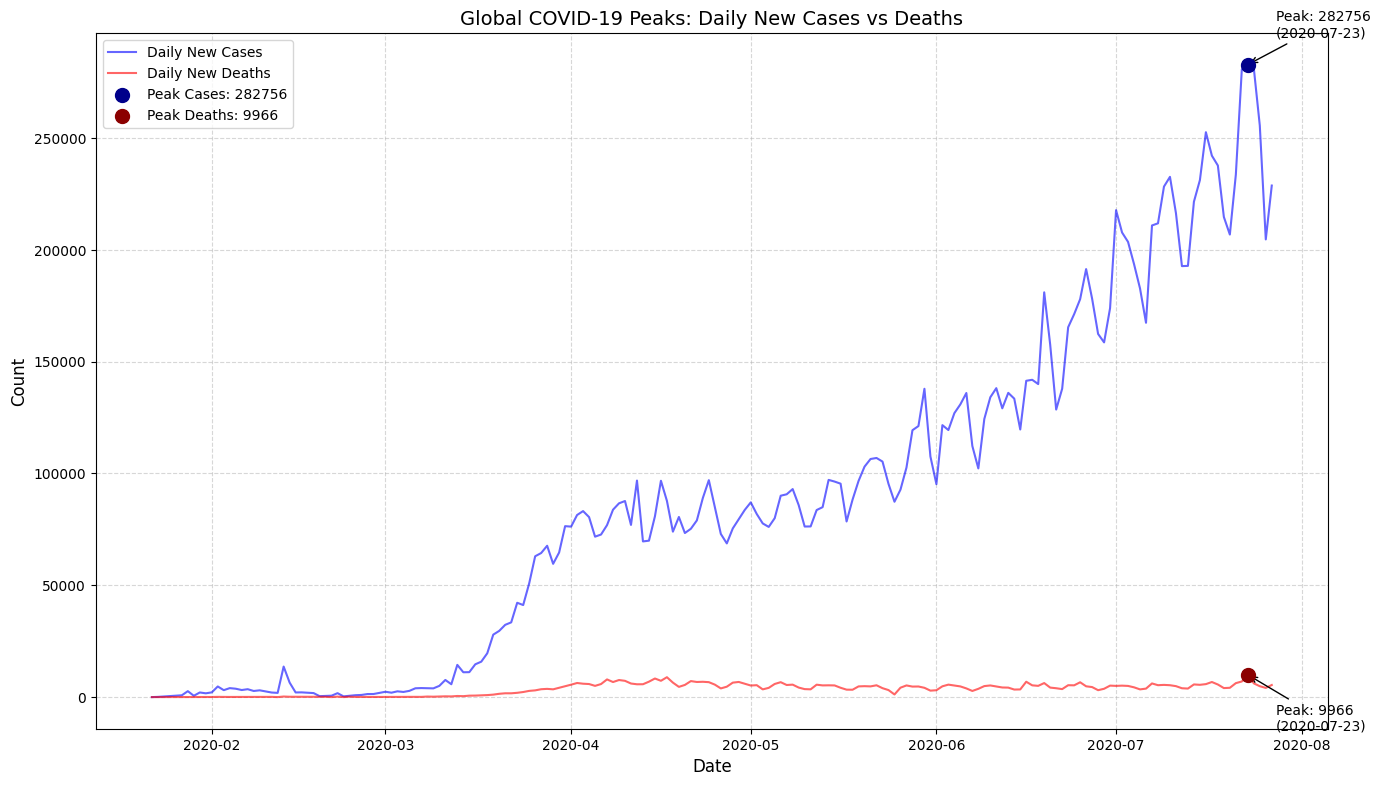

In [29]:
from pyspark.sql.functions import max, col
import matplotlib.pyplot as plt

# 1. Load the day-wise dataset
df_day = spark.read.csv("day_wise.csv", header=True, inferSchema=True)

# 2. Find the Maximum values for New Cases and New Deaths
peak_values = df_day.select(
    max("New cases").alias("Max_New_Cases"),
    max("New deaths").alias("Max_New_Deaths")
).collect()[0]

max_cases = peak_values["Max_New_Cases"]
max_deaths = peak_values["Max_New_Deaths"]

# 3. Retrieve the dates associated with these peaks
peak_cases_date = df_day.filter(col("New cases") == max_cases).select("Date").collect()[0][0]
peak_deaths_date = df_day.filter(col("New deaths") == max_deaths).select("Date").collect()[0][0]

# 4. Output the results
print(f"--- Pandemic Peaks Identified ---")
print(f"Global Peak New Cases: {max_cases} occurred on {peak_cases_date}")
print(f"Global Peak New Deaths: {max_deaths} occurred on {peak_deaths_date}")

# 5. Visualization: Line Chart with Peak Markers
# Convert to pandas for plotting the time series
pd_day = df_day.toPandas()

plt.figure(figsize=(14, 8))

# Plot the trends
plt.plot(pd_day['Date'], pd_day['New cases'], label='Daily New Cases', color='blue', alpha=0.6)
plt.plot(pd_day['Date'], pd_day['New deaths'], label='Daily New Deaths', color='red', alpha=0.6)

# Add Peak Markers (Points)
plt.scatter(peak_cases_date, max_cases, color='darkblue', s=100, label=f'Peak Cases: {max_cases}', zorder=5)
plt.scatter(peak_deaths_date, max_deaths, color='darkred', s=100, label=f'Peak Deaths: {max_deaths}', zorder=5)

# Annotate the peaks
plt.annotate(f'Peak: {max_cases}\n({peak_cases_date})', 
             xy=(peak_cases_date, max_cases), xytext=(20, 20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))

plt.annotate(f'Peak: {max_deaths}\n({peak_deaths_date})', 
             xy=(peak_deaths_date, max_deaths), xytext=(20, -40),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Global COVID-19 Peaks: Daily New Cases vs Deaths', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Module 9: Feature Engineering
Task 20: Create Severity Category

Based on confirmed cases:
Low → < 10K
Medium → 10K–100K
High → 100K–1M
Critical → >1M
Apply on country dataset.

Visualization:
Pie chart

Concepts:
when()


--- Country Distribution by Severity Category ---
+--------+-----+
|Severity|count|
+--------+-----+
|    High|   21|
|     Low|  107|
|  Medium|   56|
|Critical|    3|
+--------+-----+



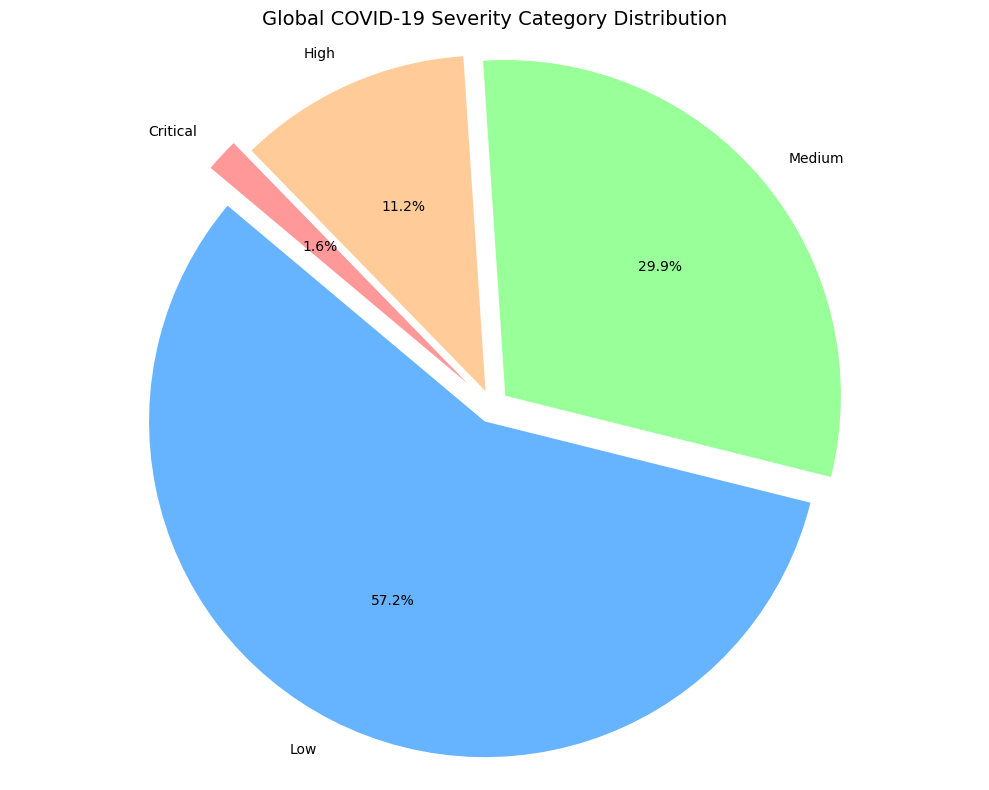

In [30]:
from pyspark.sql.functions import col, when
import matplotlib.pyplot as plt

# 1. Load the country-wise dataset
df_country = spark.read.csv("country_wise_latest.csv", header=True, inferSchema=True)

# 2. Apply Severity Categories using when()
# Logic: Low < 10K, Medium 10K-100K, High 100K-1M, Critical > 1M
df_severity = df_country.withColumn("Severity", 
    when(col("Confirmed") < 10000, "Low")
    .when((col("Confirmed") >= 10000) & (col("Confirmed") < 100000), "Medium")
    .when((col("Confirmed") >= 100000) & (col("Confirmed") < 1000000), "High")
    .when(col("Confirmed") >= 1000000, "Critical")
    .otherwise("Unknown")
)

# 3. Aggregate counts for each category
severity_summary = df_severity.groupBy("Severity").count().toPandas()

# 4. Output the table
print("--- Country Distribution by Severity Category ---")
df_severity.groupBy("Severity").count().show()

# 5. Visualization: Pie Chart
# Sort categories for logical display
severity_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
severity_summary['Order'] = severity_summary['Severity'].map(severity_order)
severity_summary = severity_summary.sort_values('Order')

plt.figure(figsize=(10, 8))
colors = ['#66b3ff','#99ff99','#ffcc99','#ff9999']
plt.pie(severity_summary['count'], 
        labels=severity_summary['Severity'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=(0.05, 0.05, 0.05, 0.1))

plt.title('Global COVID-19 Severity Category Distribution', fontsize=14)
plt.axis('equal')
plt.tight_layout()

plt.show()

Module 10: Final Mini Pipeline Project

Task 21: Build COVID Analytics Pipeline

Create a final pipeline that:

Step 1:
Extract all datasets

Step 2:
Clean missing values

Step 3:
Standardize columns

Step 4:
Join datasets

Step 5:
Generate analytics tables:

Top countries
Region summary
Daily trends
Mortality report
Recovery report

Step 6:
Store outputs as:
parquet
csv

Step 7:
Use output for visualization dashboard


In [31]:
from pyspark.sql.functions import col, when, regexp_replace, sum, max, round, count
import os

# --- STEP 1: EXTRACT ---
# Load all datasets into a dictionary for processing
files = {
    "clean_complete": "covid_19_clean_complete.csv",
    "country_wise": "country_wise_latest.csv",
    "worldometer": "worldometer_data.csv",
    "day_wise": "day_wise.csv",
    "full_grouped": "full_grouped.csv"
}

dfs = {name: spark.read.csv(path, header=True, inferSchema=True) for name, path in files.items()}

# --- STEP 2 & 3: CLEAN & STANDARDIZE ---
def clean_and_standardize(df, country_col="Country/Region"):
    # Fill missing Province/State
    if "Province/State" in df.columns:
        df = df.fillna("Unknown", subset=["Province/State"])
    
    # Standardize Country Names and remove symbols like '*'
    df = df.withColumn(country_col, regexp_replace(col(country_col), "\\*", ""))
    df = df.withColumn(country_col, 
        when(col(country_col).isin(["USA", "United States"]), "US")
        .when(col(country_col).contains("Korea"), "South Korea")
        .when(col(country_col) == "United Kingdom", "UK")
        .otherwise(col(country_col))
    )
    
    # Remove duplicates for time-series data
    if "Date" in df.columns:
        df = df.dropDuplicates([country_col, "Date"])
        
    return df

# Apply cleaning to all relevant dataframes
for name in dfs:
    dfs[name] = clean_and_standardize(dfs[name])

# --- STEP 4: JOIN ---
# Merge Worldometer (Population/Tests) with Country Wise (Latest cases)
# We rename columns to avoid confusion after join
worldometer_prep = dfs["worldometer"].select(
    col("Country/Region"), 
    col("Population"), 
    col("TotalTests")
)

country_master = dfs["country_wise"].join(worldometer_prep, on="Country/Region", how="left")

# --- STEP 5: GENERATE ANALYTICS TABLES ---

# 1. Top Countries by Confirmed Cases
top_countries = country_master.select("Country/Region", "Confirmed", "Deaths") \
    .orderBy(col("Confirmed").desc()).limit(10)

# 2. WHO Region Summary
region_summary = country_master.groupBy("WHO Region").agg(
    sum("Confirmed").alias("Total_Confirmed"),
    sum("Deaths").alias("Total_Deaths"),
    sum("Recovered").alias("Total_Recovered")
)

# 3. Daily Global Trends
daily_trends = dfs["day_wise"].select("Date", "Confirmed", "Deaths", "New cases") \
    .orderBy("Date")

# 4. Mortality & Recovery Report
mortality_recovery_report = country_master.withColumn(
    "Mortality_Rate", round((col("Deaths") / col("Confirmed")) * 100, 2)
).withColumn(
    "Recovery_Rate", round((col("Recovered") / col("Confirmed")) * 100, 2)
).select("Country/Region", "Mortality_Rate", "Recovery_Rate")

# --- STEP 6: STORE OUTPUTS ---
# Saving as CSV and Parquet for downstream BI tools
output_tables = {
    "top_countries": top_countries,
    "region_summary": region_summary,
    "daily_trends": daily_trends,
    "mortality_recovery_report": mortality_recovery_report
}

for name, df in output_tables.items():
    # Save as CSV (single file for ease of use)
    df.coalesce(1).write.mode("overwrite").option("header", "true").csv(f"output_{name}.csv")
    # Save as Parquet (optimized for large scale analytics)
    df.write.mode("overwrite").parquet(f"output_{name}.parquet")

print("Pipeline Execution Successful: 4 Analytics Tables generated and stored.")

{"ts": "2026-05-08 15:33:50.026", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `Country/Region` cannot be resolved. Did you mean one of the following? [`Confirmed`, `Active`, `Date`, `Deaths`, `New cases`]. SQLSTATE: 42703", "context": {"file": "line 23 in cell [32]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o984.withColumn.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `Country/Region` cannot be resolved. Did you mean one of the following? [`Confirmed`, `Active`, `Date`, `Deaths`, `New cases`]. SQLSTATE: 42703;\n'Project [Date#1890, Confirmed#1891, Deaths#1892, Recovered#1893, Active#1894, New cases#1895, New deaths#1896, New recovered#1897, Deaths / 100 Cases#1898, Recover

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `Country/Region` cannot be resolved. Did you mean one of the following? [`Confirmed`, `Active`, `Date`, `Deaths`, `New cases`]. SQLSTATE: 42703;
'Project [Date#1890, Confirmed#1891, Deaths#1892, Recovered#1893, Active#1894, New cases#1895, New deaths#1896, New recovered#1897, Deaths / 100 Cases#1898, Recovered / 100 Cases#1899, Deaths / 100 Recovered#1900, No. of countries#1901, 'regexp_replace('Country/Region, \*, ) AS Country/Region#1940]
+- Relation [Date#1890,Confirmed#1891,Deaths#1892,Recovered#1893,Active#1894,New cases#1895,New deaths#1896,New recovered#1897,Deaths / 100 Cases#1898,Recovered / 100 Cases#1899,Deaths / 100 Recovered#1900,No. of countries#1901] csv
